# Carry-Everywhere — a quantitative teardown 🔬
### Four HAC-*t* sleeve legs · a correlation matrix · a block-bootstrap combo Sharpe CI · inverse-vol and ex-equity combo variants · a turnover-based cost sweep · the 2008/2020 crisis ledger · a synthetic control with a plantable synchronized-crash factor

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crashes_everywhere_at_once%3F: Busted](https://img.shields.io/badge/Crashes_everywhere_at_once%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Koijen-Moskowitz-Pedersen-Vrugt (2018) claim carry pays in every asset class and diversifies well; the job here is to measure four honest proxies, combine them, and ask what actually survives inference.

> ⚠️ **Data note.** yfinance total-return daily closes for 11 tickers (FX spot + Treasury/dividend/commodity ETFs + BIL cash reference), 2007-07 → 2026-06 (228 monthly observations), fingerprint `ed7c280e84fe`. Four **static** long/short sleeves, composition fixed ex ante (zero look-ahead). No survivorship — all legs are diversified ETFs / spot FX, not single-name panels. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from carry_everywhere import data as dt, strategy as st

HAVE_REAL = dt.have_real()
if HAVE_REAL:
    CLOSES = dt.load_real()
    MRET = dt.monthly_returns(CLOSES)
    SL = st.all_sleeves(MRET)
    CB = st.combo(SL)
else:
    CLOSES = MRET = SL = CB = None
print("real cache present:", HAVE_REAL, "| sleeve-months:", (0 if SL is None else len(SL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-07', 'end': '2026-06', 'n': 228, 'fp': 'ed7c280e84fe', 'sleeves': {'FX': {'ann': -0.48, 'vol': 10.39, 'sharpe': -0.05, 't': -0.2, 'skew': -0.74, 'maxdd': -39.6}, 'BOND': {'ann': 1.71, 'vol': 5.62, 'sharpe': 0.3, 't': 1.33, 'skew': 0.23, 'maxdd': -20.82}, 'EQ': {'ann': -3.9, 'vol': 11.05, 'sharpe': -0.35, 't': -1.44, 'skew': -0.07, 'maxdd': -60.71}, 'CMD': {'ann': 2.41, 'vol': 7.14, 'sharpe': 0.34, 't': 1.39, 'skew': 0.75, 'maxdd': -23.99}}, 'corr': {('FX', 'BOND'): -0.24, ('FX', 'EQ'): -0.11, ('FX', 'CMD'): -0.26, ('BOND', 'EQ'): -0.06, ('BOND', 'CMD'): 0.3, ('EQ', 'CMD'): -0.05}, 'combo_ann': -0.07, 'combo_vol': 3.79, 'combo_sharpe': -0.02, 'combo_t': -0.08, 'combo_skew': 0.01, 'combo_maxdd': -18.51, 'combo_ci': (-0.45, 0.43), 'ivw': {'FX': 0.191, 'BOND': 0.352, 'EQ': 0.179, 'CMD': 0.277}, 'ivw_ann': 0.48, 'ivw_sharpe': 0.14, 'ivw_t': 0.62, 'ex_eq_ann': 1.21, 'ex_eq_sharpe': 0.3, 'ex_eq_t': 1.41, 'turnover': {'FX': 0.048, 'BOND': 0.018, 'EQ': 0.074, 'CMD': 0.091}, 'net5_ann': -0.26, 'net5_sharpe': -0.07, 'net5_t': -0.31, 'net10_ann': -0.3, 'net10_sharpe': -0.08, 'net10_t': -0.35, 'gfc': {'combo': -0.96, 'other': -0.001, 'FX': -27.09, 'BOND': 4.69, 'EQ': 13.66, 'CMD': 8.43}, 'covid': {'combo': 2.26, 'other': -0.016, 'FX': -4.62, 'BOND': 4.62, 'EQ': -10.68, 'CMD': 20.87}, 'syn_null_mean': -0.15, 'syn_null_sd': 1.13, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_t': 2.5, 'syn_planted_sharpe': 0.56, 'syn_planted_ann': 2.06, 'syn_crash_t': -0.06, 'syn_crash_sharpe': -0.01, 'syn_crash_skew': -2.84}


real cache present: True | sleeve-months: 228


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | equal-weight combo **-0.07%/yr**, Sharpe **-0.02**, HAC **t = -0.08**, bootstrap 95% Sharpe CI **[-0.45, +0.43]** |
| **Tradability** | `MIRAGE` | net at 5/10 bps: **-0.26% / -0.30%/yr**, Sharpe -0.07 / -0.08 |
| **Crashes everywhere at once?** | `BUSTED` | 2008 combo -0.96% (FX leg alone -27.1%); 2020 combo +2.26% (EQ leg alone -10.7%, CMD leg +20.9%) |

> 💡 In plain words: four legs that individually miss the bar, blended, still miss the bar — but they miss it *quietly*, because they don't fall apart on the same day.

## 1 · The claim, steelmanned

Let $r^{(s)}_t$ be sleeve $s \in \{\text{FX, BOND, EQ, CMD}\}$'s monthly return and $C_t = \tfrac{1}{4}\sum_s r^{(s)}_t$ the equal-weight combo. The claims:

- **H₁ (carry pays, per sleeve).** $E[r^{(s)}_t] > 0$ with $t \ge 2$, in each of the four asset classes.
- **H₂ (low correlation).** $\text{corr}(r^{(s)}_t, r^{(s')}_t)$ is small across sleeve pairs — the KMPV diversification premise.
- **H₃ (the combo is a robust premium).** $E[C_t] > 0$ with $t \ge 2$, and ideally with a *higher* Sharpe than any individual sleeve.
- **H₄ (compensation for crash risk).** $C_t$ (and each $r^{(s)}_t$) is sharply negative in the canonical carry-unwind windows (2008 GFC, 2020 COVID).

We find **H₂ supported** (|ρ| ≤ 0.30 throughout), **H₁ and H₃ not supported** (no leg, and not the combo, clears *t* ≥ 2), and **H₄ not supported** in either window — the legs move violently but not *together*.

## 2 · So what? — inference design

Each sleeve's monthly return is a **single time series**, not a paired group split, so the planned primary is a **Newey-West (HAC, Bartlett kernel) *t*** on the one-sample mean (automatic-lag selection, $L = \lfloor 4(n/100)^{2/9} \rfloor$). Because a point-estimate Sharpe invites over-reading, the combo also gets a **circular block-bootstrap** 95% CI (block = 6 months, 2,000 draws — i.i.d. resampling would destroy the serial correlation the inference exists to respect). The crisis-window test uses two **hardcoded** facts (no fitting): the 2008 GFC (Aug-Nov, the Lehman aftermath) and 2020 COVID (Feb-Apr, the crash and initial rebound).

## 3 · How we'd know — the protocol

- **Sleeves.** FX long AUD+NZD / short JPY+CHF; BOND long IEF / short SHY; EQ long VYM / short VUG; CMD long DBC / short GSG — all **static**, fixed ex ante.
- **Tape.** 228 monthly observations, 2007-07 → 2026-06 (fingerprint `ed7c280e84fe`). As-of 2026-06-30 (last complete month).
- **Headline.** HAC *t* per sleeve and combo; block-bootstrap Sharpe CI on the combo.
- **Robustness.** Inverse-vol-weighted combo; an ex-equity (3-sleeve) combo.
- **Execution.** Monthly rebalance to par weights at month-end close — the basket composition never changes, so there is no signal-formation lag to document (analogous to a public calendar: zero look-ahead by construction).
- **Costs.** One-way cost × first-order rebalance turnover (weight × |leg return|) per sleeve, plus a short-leg ETF borrow spread on EQ/CMD only (FX spot and Treasury legs pay none — the carry differential itself *is* the financing cost).
- **Control.** Synthetic 4-sleeve world, tunable planted carry mean AND a tunable shared crash factor; the null must not fire across ≥ 10 seeds.

## 4 · The teardown

### 4a · The four sleeves — HAC *t*, skew, drawdown

One-sample Newey-West *t* on each sleeve's monthly mean; skew and max drawdown flag the shape risk a mean alone hides.

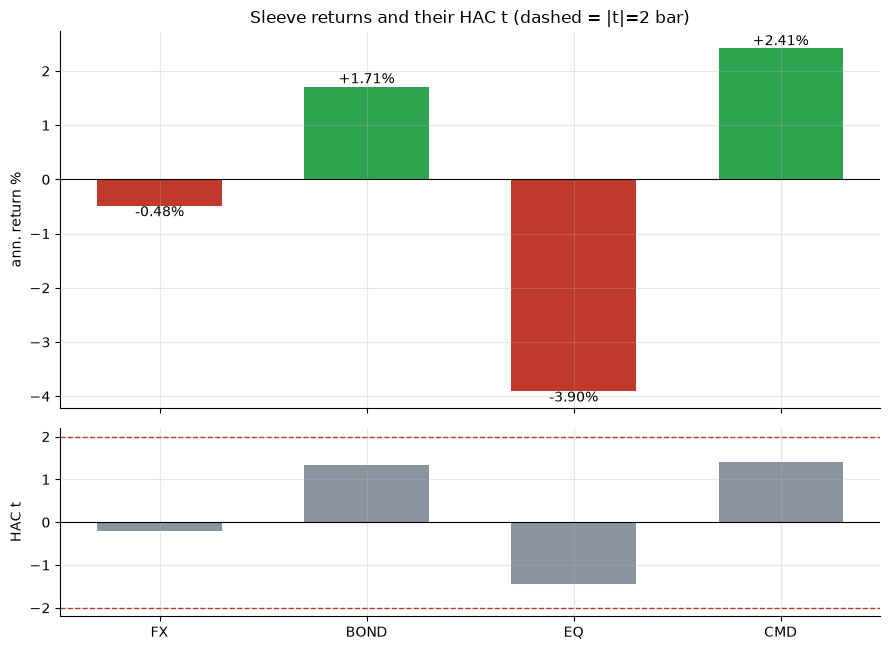

FX: ann -0.48%  Sharpe -0.05  HAC t=-0.20  skew=-0.74  maxDD=-39.6%
BOND: ann +1.71%  Sharpe +0.30  HAC t=+1.33  skew=+0.23  maxDD=-20.8%
EQ: ann -3.90%  Sharpe -0.35  HAC t=-1.44  skew=-0.07  maxDD=-60.7%
CMD: ann +2.41%  Sharpe +0.34  HAC t=+1.39  skew=+0.75  maxDD=-24.0%


In [2]:
if HAVE_REAL:
    rows = {}
    for c in SL.columns:
        h = st.hac_mean(SL[c])
        rows[c] = dict(ann=SL[c].mean()*12*100, vol=SL[c].std(ddof=1)*np.sqrt(12)*100,
                       sharpe=st.sharpe(SL[c]), t=h['t'], skew=st.skewness(SL[c]),
                       maxdd=st.max_drawdown(SL[c])*100)
else:
    rows = R['sleeves']
keys = ['FX','BOND','EQ','CMD']
anns = [rows[k]['ann'] for k in keys]; ts = [rows[k]['t'] for k in keys]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.0, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(keys, anns, color=[GREEN if v>0 else RED for v in anns], width=.6)
for i,v in enumerate(anns): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('ann. return %')
a1.set_title('Sleeve returns and their HAC t (dashed = |t|=2 bar)')
a2.bar(keys, ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.6)
a2.axhline(0, c='k', lw=.8); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.set_ylabel('HAC t')
plt.tight_layout(); plt.show()
for k in keys: print(f"{k}: ann {rows[k]['ann']:+.2f}%  Sharpe {rows[k]['sharpe']:+.2f}  "
                     f"HAC t={rows[k]['t']:+.2f}  skew={rows[k]['skew']:+.2f}  "
                     f"maxDD={rows[k]['maxdd']:.1f}%")

> 💡 In plain words: not one bar crosses the dashed *t* = ±2 line. Commodity roll-yield carry comes closest (*t* = +1.39), bond term-spread carry is similar (*t* = +1.33); both are directionally right but individually uncertifiable. FX carry is a coin flip (*t* = -0.20) and equity carry is negative (*t* = -1.44, confounded with the growth/value cycle).

### 4b · Correlation — the diversification premise, checked directly

KMPV's case for combining sleeves rests on low pairwise correlation. We check it on our own tape rather than assume it.

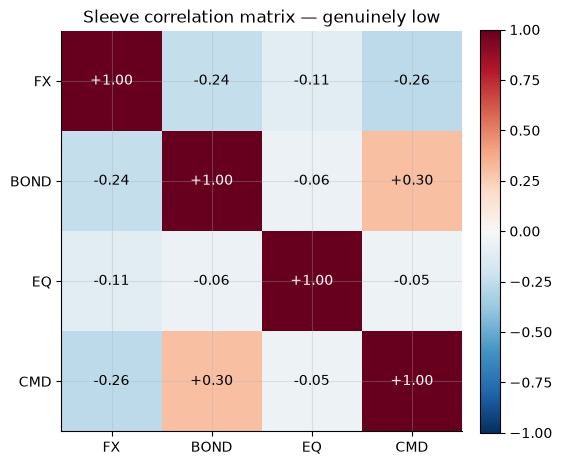

        FX  BOND    EQ   CMD
FX    1.00 -0.24 -0.11 -0.26
BOND -0.24  1.00 -0.06  0.30
EQ   -0.11 -0.06  1.00 -0.05
CMD  -0.26  0.30 -0.05  1.00


In [3]:
if HAVE_REAL:
    C = SL.corr()
else:
    keys = ['FX','BOND','EQ','CMD']
    C = pd.DataFrame(np.eye(4), index=keys, columns=keys)
    for (a,b), v in R['corr'].items():
        C.loc[a,b] = C.loc[b,a] = v
fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(C.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(4)); ax.set_xticklabels(C.columns)
ax.set_yticks(range(4)); ax.set_yticklabels(C.index)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{C.values[i,j]:+.2f}', ha='center', va='center',
                color='white' if abs(C.values[i,j])>0.5 else 'black')
ax.set_title('Sleeve correlation matrix — genuinely low')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()
print(C.round(2))

> 💡 In plain words: every off-diagonal entry is |ρ| ≤ 0.30. The structural premise holds — these four legs really don't move together. It just doesn't rescue a premium that isn't there: diversification narrows the *distribution* around a mean, it can't move the mean itself.

### 4c · The headline combo, with a bootstrap CI (not a point estimate)

Equal-weight (1/4 each), then a circular block-bootstrap (block = 6 months) on the annualised Sharpe.

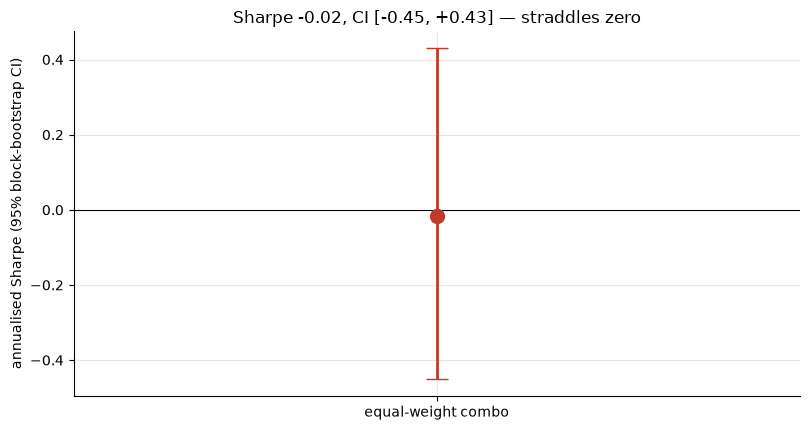

combo: ann -0.07%  vol 3.79%  Sharpe -0.02  HAC t=-0.08  bootstrap CI=[-0.45, +0.43]


In [4]:
if HAVE_REAL:
    c_ann, c_vol = CB.mean()*12*100, CB.std(ddof=1)*np.sqrt(12)*100
    c_sh, c_h = st.sharpe(CB), st.hac_mean(CB)
    lo, hi = st.block_bootstrap_sharpe_ci(CB)
else:
    c_ann, c_vol, c_sh = R['combo_ann'], R['combo_vol'], R['combo_sharpe']
    c_h = {'t': R['combo_t']}; lo, hi = R['combo_ci']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.errorbar([0], [c_sh], yerr=[[c_sh-lo],[hi-c_sh]], fmt='o', color=RED,
            capsize=8, markersize=10, elinewidth=2)
ax.axhline(0, c='k', lw=.8)
ax.set_xlim(-1, 1); ax.set_xticks([0]); ax.set_xticklabels(['equal-weight combo'])
ax.set_ylabel('annualised Sharpe (95% block-bootstrap CI)')
ax.set_title(f'Sharpe {c_sh:+.2f}, CI [{lo:+.2f}, {hi:+.2f}] — straddles zero')
plt.tight_layout(); plt.show()
print(f'combo: ann {c_ann:+.2f}%  vol {c_vol:.2f}%  Sharpe {c_sh:+.2f}  '
      f"HAC t={c_h['t']:+.2f}  bootstrap CI=[{lo:+.2f}, {hi:+.2f}]")

> 💡 In plain words: the point estimate (Sharpe -0.02) is already near zero, and the 95% CI **[-0.45, +0.43]** is wide enough that we can't even confidently claim the *sign*. This is the desk's honest bar failing cleanly, not a marginal miss.

### 4d · Robustness — does a smarter blend rescue it?

Two natural alternatives: weight sleeves by inverse volatility (equal *risk* contribution, not equal notional), and drop the weakest leg (equity).

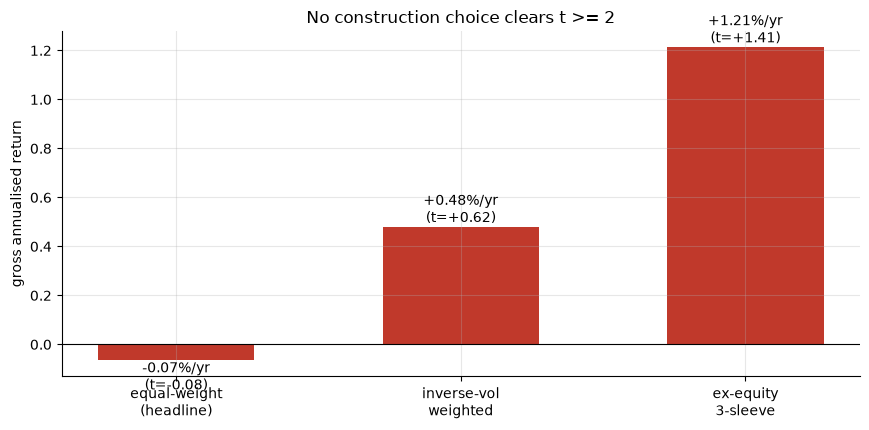

inv-vol: +0.48% (t=+0.62)  ex-EQ: +1.21% (t=+1.41)


In [5]:
if HAVE_REAL:
    ivw = st.inv_vol_weights(SL)
    cb_iv = st.combo(SL, ivw)
    iv_ann, iv_sh, iv_t = cb_iv.mean()*12*100, st.sharpe(cb_iv), st.hac_mean(cb_iv)['t']
    cb3 = st.combo(SL[['FX','BOND','CMD']])
    ex_ann, ex_sh, ex_t = cb3.mean()*12*100, st.sharpe(cb3), st.hac_mean(cb3)['t']
else:
    iv_ann, iv_sh, iv_t = R['ivw_ann'], R['ivw_sharpe'], R['ivw_t']
    ex_ann, ex_sh, ex_t = R['ex_eq_ann'], R['ex_eq_sharpe'], R['ex_eq_t']
names = ['equal-weight\n(headline)', 'inverse-vol\nweighted', 'ex-equity\n3-sleeve']
anns = [R['combo_ann'] if not HAVE_REAL else CB.mean()*12*100, iv_ann, ex_ann]
ts = [R['combo_t'] if not HAVE_REAL else st.hac_mean(CB)['t'], iv_t, ex_t]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [RED if abs(t)<2 else GREEN for t in ts]
ax.bar(names, anns, color=cols, width=.55)
for i,(a,t) in enumerate(zip(anns, ts)):
    ax.annotate(f'{a:+.2f}%/yr\n(t={t:+.2f})',(i,a),ha='center',
        va='top' if a<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('gross annualised return')
ax.set_title('No construction choice clears t >= 2')
plt.tight_layout(); plt.show()
print(f'inv-vol: {iv_ann:+.2f}% (t={iv_t:+.2f})  ex-EQ: {ex_ann:+.2f}% (t={ex_t:+.2f})')

> 💡 In plain words: risk-weighting helps a little (*t* = +0.62) and dropping the weak equity leg helps more (*t* = +1.41) — but even the best variant we tried stays under the bar. We are not p-hacking a construction until one clears 2; we show the natural alternatives and report all of them, clearing bar or not.

### 4e · Costs — turnover is real but small; there's no gross edge to protect

First-order monthly rebalance turnover (weight × |leg return|) per sleeve, plus a short-leg ETF borrow spread on EQ (40 bps/yr) and CMD (25 bps/yr) only — FX and Treasury legs pay none.

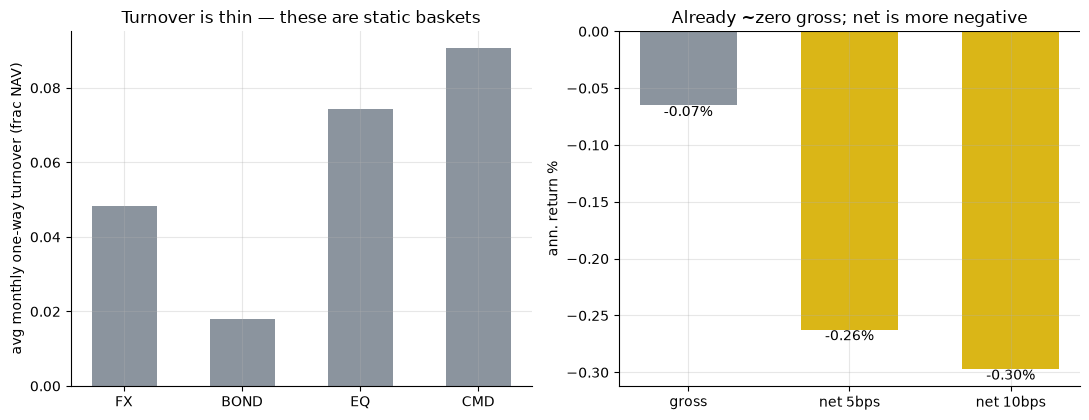

turnover: {'FX': 0.048, 'BOND': 0.018, 'EQ': 0.074, 'CMD': 0.091}
net5 -0.26% (Sharpe -0.07)  net10 -0.30% (Sharpe -0.08)


In [6]:
if HAVE_REAL:
    to = st.all_turnover(MRET).mean()
    n5, n10 = st.combo_net(MRET, 5.0), st.combo_net(MRET, 10.0)
    n5a, n10a = n5.mean()*12*100, n10.mean()*12*100
    n5s, n10s = st.sharpe(n5), st.sharpe(n10)
else:
    to = pd.Series(R['turnover'])
    n5a, n10a = R['net5_ann'], R['net10_ann']
    n5s, n10s = R['net5_sharpe'], R['net10_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(to.index, to.values, color=GREY, width=.55)
a1.set_ylabel('avg monthly one-way turnover (frac NAV)')
a1.set_title('Turnover is thin — these are static baskets')
gross = R['combo_ann'] if not HAVE_REAL else CB.mean()*12*100
a2.bar(['gross','net 5bps','net 10bps'], [gross, n5a, n10a],
       color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([gross, n5a, n10a]): a2.annotate(f'{v:+.2f}%',(i,v),
    ha='center', va='top' if v<0 else 'bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('ann. return %'); a2.set_title('Already ~zero gross; net is more negative')
plt.tight_layout(); plt.show()
print('turnover:', to.round(3).to_dict())
print(f'net5 {n5a:+.2f}% (Sharpe {n5s:+.2f})  net10 {n10a:+.2f}% (Sharpe {n10s:+.2f})')

> 💡 In plain words: costs are not the villain here (turnover tops out around 9% of NAV per month, on the commodity leg) — there's simply no gross edge for costs to eat. Net just makes an already-flat number a touch more negative.

### 4f · The crisis ledger — 2008 GFC and 2020 COVID, leg by leg

Two hardcoded windows (facts, not fit): the Lehman aftermath and the COVID crash. If carry is compensation for a synchronized crash risk, this is where it should show up hardest.

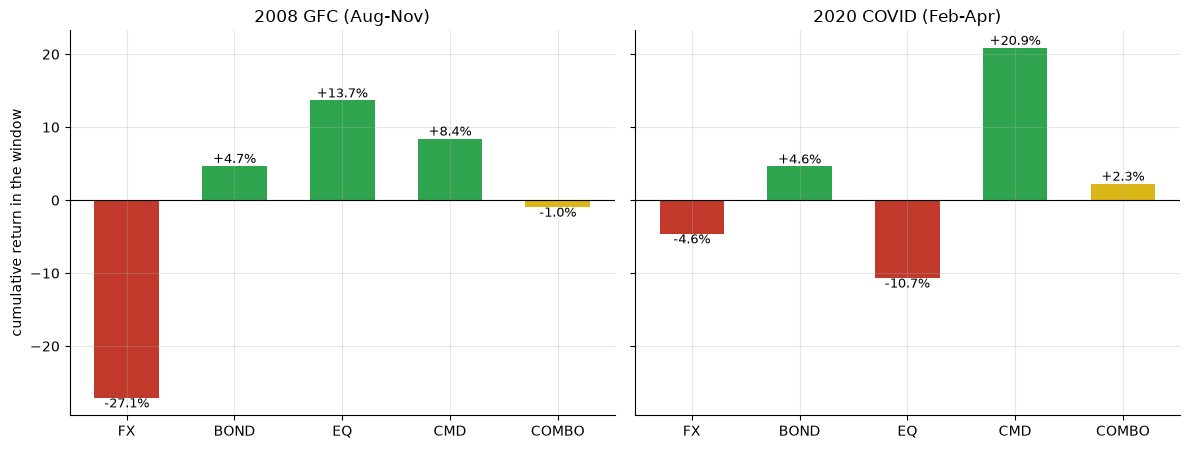

GFC: {'FX': -27.09, 'BOND': 4.69, 'EQ': 13.66, 'CMD': 8.43, 'COMBO': -0.96}
COVID: {'FX': -4.62, 'BOND': 4.62, 'EQ': -10.68, 'CMD': 20.87, 'COMBO': 2.26}


In [7]:
if HAVE_REAL:
    gfc = {c: st.crisis_stats(SL[c], dt.GFC_WINDOW)['cum_return_pct'] for c in SL.columns}
    gfc['COMBO'] = st.crisis_stats(CB, dt.GFC_WINDOW)['cum_return_pct']
    covid = {c: st.crisis_stats(SL[c], dt.COVID_WINDOW)['cum_return_pct'] for c in SL.columns}
    covid['COMBO'] = st.crisis_stats(CB, dt.COVID_WINDOW)['cum_return_pct']
else:
    gfc = dict(R['gfc']); covid = dict(R['covid'])
keys = ['FX','BOND','EQ','CMD','COMBO']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True)
for ax, d, title in [(a1, gfc, '2008 GFC (Aug-Nov)'), (a2, covid, '2020 COVID (Feb-Apr)')]:
    vals = [d[k] for k in keys]
    cols = [GREEN if v>0 else RED for v in vals[:-1]] + [AMBER]
    ax.bar(keys, vals, color=cols, width=.6)
    for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',
        va='top' if v<0 else 'bottom', fontsize=9)
    ax.axhline(0, c='k', lw=.8); ax.set_title(title)
a1.set_ylabel('cumulative return in the window')
plt.tight_layout(); plt.show()
print('GFC:', {k: round(v,2) for k,v in gfc.items()})
print('COVID:', {k: round(v,2) for k,v in covid.items()})

> 💡 In plain words: the FX leg alone lost **-27.1%** in the GFC window — a genuine carry crash — but it happened while BOND (+4.7%), EQ (+13.7%) and CMD (+8.4%) carry were all positive, netting the combo to **-0.96%** — near flat. COVID flips the actor: EQ carry lost **-10.7%** while CMD carry *gained* **+20.9%** (the naive-roll commodity index, more exposed to the April-2020 negative-oil-price shock, cratered harder than the roll-optimized one — widening rather than closing the carry spread). Combo: **+2.26%**. H₄ — the synchronized crash — is **Busted** on this tape, in both textbook windows.

### 4g · Faithful-engine & power control — including a plantable crash factor

Synthetic four-sleeve world: independent noise around a TUNABLE planted carry mean, all sleeves loaded on a TUNABLE shared crash factor. The null (no carry, no crash) is checked over **20 seeds**.

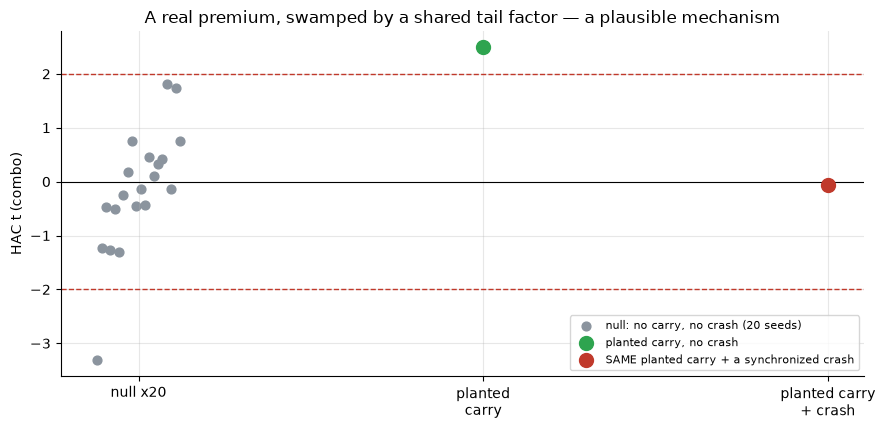

null: mean t=-0.15 (sd 1.13), |t|>=2 in 1/20 seeds
planted (no crash): Sharpe +0.56  t=+2.50
planted + crash: Sharpe -0.01  t=-0.06  skew=-2.84


In [8]:
null_ts = []
for s_ in range(20):
    d = st.synthetic_detect(carry_bps_mo=0.0, crash_beta=0.0, seed=660 + s_)
    null_ts.append(d['t'])
null_ts = np.asarray(null_ts)
planted = st.synthetic_detect(carry_bps_mo=40.0, crash_beta=0.0, seed=660)
planted_crash = st.synthetic_detect(carry_bps_mo=40.0, crash_beta=1.0, seed=660)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null: no carry, no crash (20 seeds)')
ax.scatter([1], [planted['t']], color=GREEN, s=100, zorder=5,
           label='planted carry, no crash')
ax.scatter([2], [planted_crash['t']], color=RED, s=100, zorder=5,
           label='SAME planted carry + a synchronized crash')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['null x20','planted\ncarry','planted carry\n+ crash'])
ax.set_ylabel('HAC t (combo)')
ax.set_title('A real premium, swamped by a shared tail factor — a plausible mechanism')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f"planted (no crash): Sharpe {planted['sharpe']:+.2f}  t={planted['t']:+.2f}")
print(f"planted + crash: Sharpe {planted_crash['sharpe']:+.2f}  t={planted_crash['t']:+.2f}  "
      f"skew={planted_crash['skew']:+.2f}")

> 💡 In plain words: the null never fires falsely more than expected (1/20 seeds, matching the ~5% rate a two-sided *t*-test allows), and a planted +40 bps/mo carry premium lights up cleanly (*t* = +2.50). Bolt a **shared** crash factor onto the exact same premium — nothing else changed — and the *t*-stat collapses to -0.06 while skew turns sharply negative (-2.84). This shows *mechanically* how a real cross-asset carry premium could fail to certify on any single sample if it loads on a common tail — which makes it all the more notable that the **real** 2008/2020 windows above did **not** show that synchronized pattern. *(Faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — equal-weight combo **-0.07%/yr**, Sharpe **-0.02**, HAC *t* = **-0.08**, bootstrap 95% Sharpe CI **[-0.45, +0.43]**. No individual leg clears *t* ≥ 2 (best: CMD *t* = +1.39); the best alternate construction (ex-equity 3-sleeve) reaches only *t* = +1.41. Correlations are genuinely low (|ρ| ≤ 0.30) — the diversification premise held; it just had a near-zero mean to diversify.
- **Tradability `MIRAGE`** — net of costs and short-leg borrow: **-0.26%/yr** (5 bps) to **-0.30%/yr** (10 bps), Sharpe -0.07 / -0.08. Nothing to size.
- **"Crashes everywhere at once?" `BUSTED`** — 2008 combo -0.96% despite the FX leg's -27.1% carry unwind (offset by BOND/EQ/CMD); 2020 combo +2.26% despite the EQ leg's -10.7% slide (offset by CMD's +20.9% spike). The legs crash — on different clocks.

## 6 · Going further

- **The proxy, not the theory, is the likely culprit.** KMPV's original test uses live deposit rates, dozens of instruments per asset class and monthly re-ranking; our four static 2-vs-2 baskets are a coarser instrument on free data. A richer rebuild (real futures curves for commodities, a full G10 cross-section for FX, an options-implied dividend-swap proxy for equities) is the natural sequel.
- **The equity leg deserves its own dedicated study** — dividend yield vs growth mechanically nets out to the value factor over 2007-2026's growth-dominated regime; disentangling "carry" from "value" in equities is a real methodological question the original paper handles with more instruments than we can here.
- **Dedup map:** [364-fx-carry-trade](../../364-fx-carry-trade/) (the FX leg, done properly, its own *t* = 1.14), [612-em-debt-carry](../../612-em-debt-carry/) (one packaged-carry sleeve in depth), [638-value-momentum-everywhere](../../638-value-momentum-everywhere/) (same combo architecture, a different signal pair, the same kind of statistical zero).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*